Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       380
           1       1.00      0.94      0.97       320

    accuracy                           0.97       700
   macro avg       0.98      0.97      0.97       700
weighted avg       0.97      0.97      0.97       700



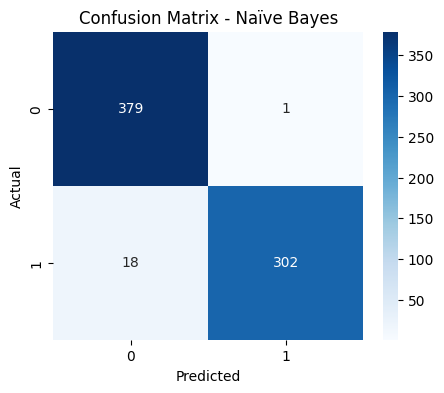

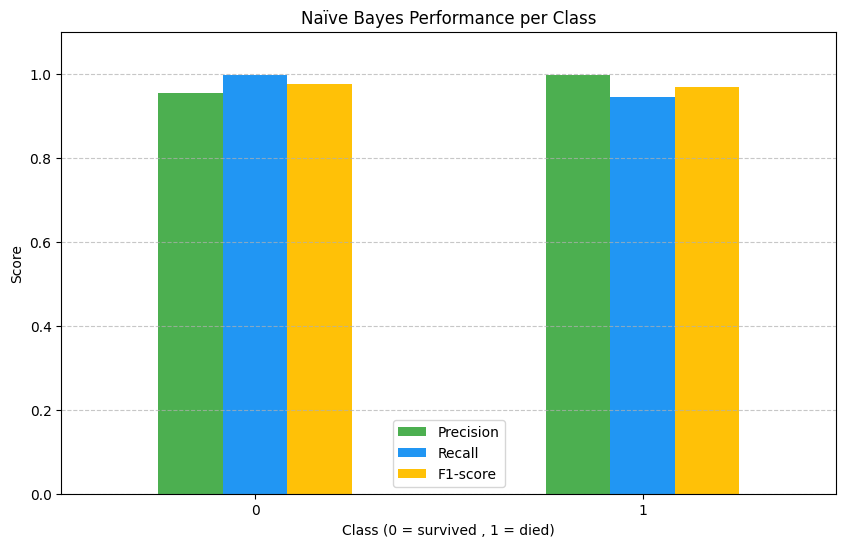

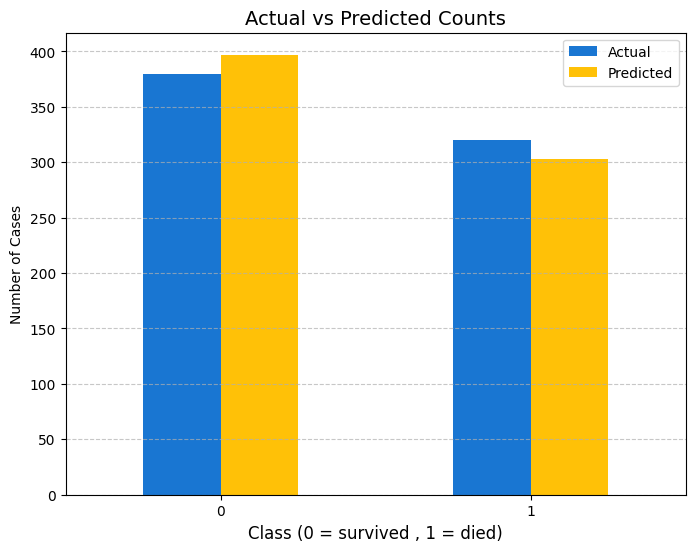

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report,roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
df = pd.read_csv('cancer_risk1.csv')
# Prepare data for training
X = df.drop(columns=['Patient_ID', 'Outcome','Obesity'])
y = df['Outcome']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
# Create and train Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Naïve Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Bar Chart for performance metrics
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report[['precision', 'recall', 'f1-score']].iloc[:-3].plot(
kind='bar',
figsize=(10, 6),
color=['#4CAF50', '#2196F3', '#FFC107']
)
plt.title('Naïve Bayes Performance per Class')
plt.xlabel('Class (0 = survived , 1 = died)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(['Precision', 'Recall', 'F1-score'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
# Bar Chart for Actual vs Predicted counts
actual_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()
compare_df = pd.DataFrame({
'Actual': actual_counts,
'Predicted': predicted_counts
})
compare_df.plot(kind='bar', figsize=(8,6), color=['#1976D2', '#FFC107'])
# Add title and labels
plt.title('Actual vs Predicted Counts', fontsize=14)
plt.xlabel('Class (0 = survived , 1 = died)', fontsize=12)
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.legend(['Actual', 'Predicted'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

